# Task 3 – Interne Evaluation der 18 Runs

Dieses Notebook berechnet für alle 18 Task-3-Runs die gleichen Metriken wie Lennards Task-A-Evaluation:
- **Cosine Mean / Std** (TF-IDF-basierte Kosinus-Ähnlichkeit)
- **SBERT Mean / Std** (Sentence-BERT-Ähnlichkeit)

Verglichen wird jeweils die **Top-1-Vorhersage** des Runs mit der echten letzten Query der Session (Ground Truth).

> ⚠️ **Hinweis:** Nur ausführen wenn geklärt ist, dass die Session-Daten als Development-Set (nicht echter Test-Set) verwendet werden dürfen.

In [1]:
%pip install scikit-learn sentence-transformers --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import zipfile
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

BASE_DIR = Path().cwd()
RUNFILES_DIR = BASE_DIR / 'runfiles_task3'

SNAPSHOT_CSVs = {
    'snapshot-1.jsonl': BASE_DIR / 'predetermined_queries_Task_A_test.csv',
    'snapshot-2.jsonl': BASE_DIR / 'task3_longeval_usim-sessions-06-08_2025.csv',
    'snapshot-3.jsonl': BASE_DIR / 'task3_longeval_usim-sessions-09-11_2025.csv',
}

print('Setup fertig.')

Setup fertig.


## 1. Ground Truth laden

Ground Truth = die **letzte Query** jeder Session (die, die das Modell vorhersagen soll).

In [3]:
def load_ground_truth(csv_path):
    """Gibt dict {session_id: letzte_query} zurück (nur Sessions mit >1 Query)."""
    df = pd.read_csv(csv_path, header=None)
    df.columns = ['idx', 'user', 'session_id', 'query', 'timestamp',
                  'retrieved_docs', 'session_hash', 'interactions']
    sessions = defaultdict(list)
    for _, row in df.sort_values('timestamp').iterrows():
        sessions[str(row['session_id'])].append(str(row['query']))
    return {sid: qs[-1] for sid, qs in sessions.items() if len(qs) > 1}

ground_truth = {}
for snap_name, csv_path in SNAPSHOT_CSVs.items():
    gt = load_ground_truth(csv_path)
    ground_truth[snap_name] = gt
    print(f'{snap_name}: {len(gt)} Sessions mit Ground Truth')

snapshot-1.jsonl: 35 Sessions mit Ground Truth
snapshot-2.jsonl: 119 Sessions mit Ground Truth
snapshot-3.jsonl: 182 Sessions mit Ground Truth


## 2. Runs laden

Alle 18 ZIP-Dateien aus `runfiles_task3/` werden eingelesen.
Pro Run und Snapshot wird die **Top-1-Vorhersage** extrahiert.

In [4]:
def load_run(zip_path):
    """Gibt dict {snap_name: {session_id: top1_query}} zurück."""
    result = {}
    with zipfile.ZipFile(zip_path) as zf:
        for snap_name in ['snapshot-1.jsonl', 'snapshot-2.jsonl', 'snapshot-3.jsonl']:
            if snap_name not in zf.namelist():
                continue
            data = json.loads(zf.read(snap_name))
            snap_result = {}
            for sid, val in data.items():
                if sid == 'meta':
                    continue
                if isinstance(val, list) and len(val) > 0:
                    snap_result[str(sid)] = str(val[0])  # Top-1
            result[snap_name] = snap_result
    return result

zip_files = sorted(RUNFILES_DIR.glob('*.zip'))
print(f'Gefundene Runs: {len(zip_files)}')
for z in zip_files:
    print(f'  {z.name}')

Gefundene Runs: 18
  task3_submission_openai_all_A_contrastive.zip
  task3_submission_openai_all_A_non_rel.zip
  task3_submission_openai_all_A_rel.zip
  task3_submission_openai_all_B_contrastive.zip
  task3_submission_openai_all_B_non_rel.zip
  task3_submission_openai_all_B_rel.zip
  task3_submission_openai_first_A_contrastive.zip
  task3_submission_openai_first_A_non_rel.zip
  task3_submission_openai_first_A_rel.zip
  task3_submission_openai_first_B_contrastive.zip
  task3_submission_openai_first_B_non_rel.zip
  task3_submission_openai_first_B_rel.zip
  task3_submission_openai_last_A_contrastive.zip
  task3_submission_openai_last_A_non_rel.zip
  task3_submission_openai_last_A_rel.zip
  task3_submission_openai_last_B_contrastive.zip
  task3_submission_openai_last_B_non_rel.zip
  task3_submission_openai_last_B_rel.zip


## 3. Metriken berechnen

### Cosine-Ähnlichkeit (TF-IDF)
TF-IDF-Vektoren werden über alle Paare (predicted, ground_truth) gemeinsam berechnet, dann wird die paarweise Cosinus-Ähnlichkeit ermittelt.

### SBERT-Ähnlichkeit
Sentence-BERT (`all-MiniLM-L6-v2`) kodiert beide Texte als Dense Embeddings, die Ähnlichkeit wird als Cosinus-Ähnlichkeit berechnet.

In [5]:
from sentence_transformers import SentenceTransformer

print('Lade SBERT-Modell (all-MiniLM-L6-v2)...')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Modell geladen.')


def compute_metrics(predicted_list, gt_list):
    """Berechnet Cosine- und SBERT-Ähnlichkeit für zwei gleichlange Listen."""
    assert len(predicted_list) == len(gt_list)
    if len(predicted_list) == 0:
        return 0.0, 0.0, 0.0, 0.0

    # Cosine (TF-IDF)
    all_texts = predicted_list + gt_list
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    tfidf_matrix = vectorizer.fit_transform(all_texts)
    n = len(predicted_list)
    pred_vecs = tfidf_matrix[:n]
    gt_vecs   = tfidf_matrix[n:]
    cosine_scores = [
        cosine_similarity(pred_vecs[i], gt_vecs[i])[0][0]
        for i in range(n)
    ]

    # SBERT
    pred_emb = sbert_model.encode(predicted_list, convert_to_numpy=True, show_progress_bar=False)
    gt_emb   = sbert_model.encode(gt_list,        convert_to_numpy=True, show_progress_bar=False)
    sbert_scores = [
        float(cosine_similarity([pred_emb[i]], [gt_emb[i]])[0][0])
        for i in range(n)
    ]

    return (
        round(float(np.mean(cosine_scores)), 4),
        round(float(np.std(cosine_scores)),  4),
        round(float(np.mean(sbert_scores)),  4),
        round(float(np.std(sbert_scores)),   4),
    )

Lade SBERT-Modell (all-MiniLM-L6-v2)...
Modell geladen.


## 4. Alle 18 Runs evaluieren

In [6]:
results = []

for zip_path in zip_files:
    run_name = zip_path.stem.replace('task3_submission_', '')
    print(f'Evaluiere: {run_name} ...', end=' ')

    run_data = load_run(zip_path)

    all_predicted = []
    all_gt        = []

    for snap_name, gt_dict in ground_truth.items():
        snap_preds = run_data.get(snap_name, {})
        for sid, gt_query in gt_dict.items():
            if sid in snap_preds:
                all_predicted.append(snap_preds[sid])
                all_gt.append(gt_query)

    cos_mean, cos_std, sbert_mean, sbert_std = compute_metrics(all_predicted, all_gt)

    results.append({
        'Run':         run_name,
        'Matches':     len(all_predicted),
        'Cosine Mean': cos_mean,
        'Cosine Std':  cos_std,
        'SBERT Mean':  sbert_mean,
        'SBERT Std':   sbert_std,
    })
    print(f'Cosine={cos_mean:.4f}, SBERT={sbert_mean:.4f}  ({len(all_predicted)} Sessions)')

results_df = pd.DataFrame(results).sort_values('SBERT Mean', ascending=False).reset_index(drop=True)
print('\nFertig!')
results_df

Evaluiere: openai_all_A_contrastive ... Cosine=0.1238, SBERT=0.3300  (336 Sessions)
Evaluiere: openai_all_A_non_rel ... Cosine=0.1242, SBERT=0.3311  (336 Sessions)
Evaluiere: openai_all_A_rel ... Cosine=0.1219, SBERT=0.3192  (336 Sessions)
Evaluiere: openai_all_B_contrastive ... Cosine=0.2433, SBERT=0.5168  (336 Sessions)
Evaluiere: openai_all_B_non_rel ... Cosine=0.2457, SBERT=0.5187  (336 Sessions)
Evaluiere: openai_all_B_rel ... Cosine=0.2185, SBERT=0.4952  (336 Sessions)
Evaluiere: openai_first_A_contrastive ... Cosine=0.1333, SBERT=0.3326  (336 Sessions)
Evaluiere: openai_first_A_non_rel ... Cosine=0.1237, SBERT=0.3266  (336 Sessions)
Evaluiere: openai_first_A_rel ... Cosine=0.1168, SBERT=0.3202  (336 Sessions)
Evaluiere: openai_first_B_contrastive ... Cosine=0.2294, SBERT=0.5011  (336 Sessions)
Evaluiere: openai_first_B_non_rel ... Cosine=0.2271, SBERT=0.5075  (336 Sessions)
Evaluiere: openai_first_B_rel ... Cosine=0.2174, SBERT=0.4982  (336 Sessions)
Evaluiere: openai_last_A_con

,Run,Matches,Cosine Mean,Cosine Std,SBERT Mean,SBERT Std
0,openai_last_B_contrastive,336,0.2471,0.1993,0.5195,0.2233
1,openai_last_B_non_rel,336,0.2360,0.1928,0.5188,0.2238
2,openai_all_B_non_rel,336,0.2457,0.1989,0.5187,0.2255
3,openai_all_B_contrastive,336,0.2433,0.1962,0.5168,0.2191
4,openai_first_B_non_rel,336,0.2271,0.1924,0.5075,0.2256
5,openai_last_B_rel,336,0.2318,0.2054,0.5062,0.2353
6,openai_first_B_contrastive,336,0.2294,0.1947,0.5011,0.2318
7,openai_first_B_rel,336,0.2174,0.1973,0.4982,0.2349
8,openai_all_B_rel,336,0.2185,0.1930,0.4952,0.2309
9,openai_first_A_contrastive,336,0.1333,0.1860,0.3326,0.3149


## 5. Ergebnisse speichern

In [7]:
output_path = BASE_DIR / 'data' / 'task3_evaluation_results.csv'
results_df.to_csv(output_path, index=False)
print(f'Gespeichert: {output_path}')

# Übersicht nach Prompt-Variante
print('\n── Mittelwerte nach Prompt-Variante ──')
results_df['Prompt'] = results_df['Run'].str.extract(r'_(A|B)_')
print(results_df.groupby('Prompt')[['Cosine Mean','SBERT Mean']].mean().round(4))

# Übersicht nach Query-Modus
print('\n── Mittelwerte nach Query-Modus ──')
results_df['Mode'] = results_df['Run'].str.extract(r'openai_(first|last|all)_')
print(results_df.groupby('Mode')[['Cosine Mean','SBERT Mean']].mean().round(4))

Gespeichert: c:\Users\Robin\TH_Koeln\Semester_5\DIS18\Abgabe\data\task3_evaluation_results.csv

── Mittelwerte nach Prompt-Variante ──
        Cosine Mean  SBERT Mean
Prompt                         
A            0.1241      0.3261
B            0.2329      0.5091

── Mittelwerte nach Query-Modus ──
       Cosine Mean  SBERT Mean
Mode                          
all         0.1796      0.4185
first       0.1746      0.4144
last        0.1814      0.4200


## 6. Visualisierung

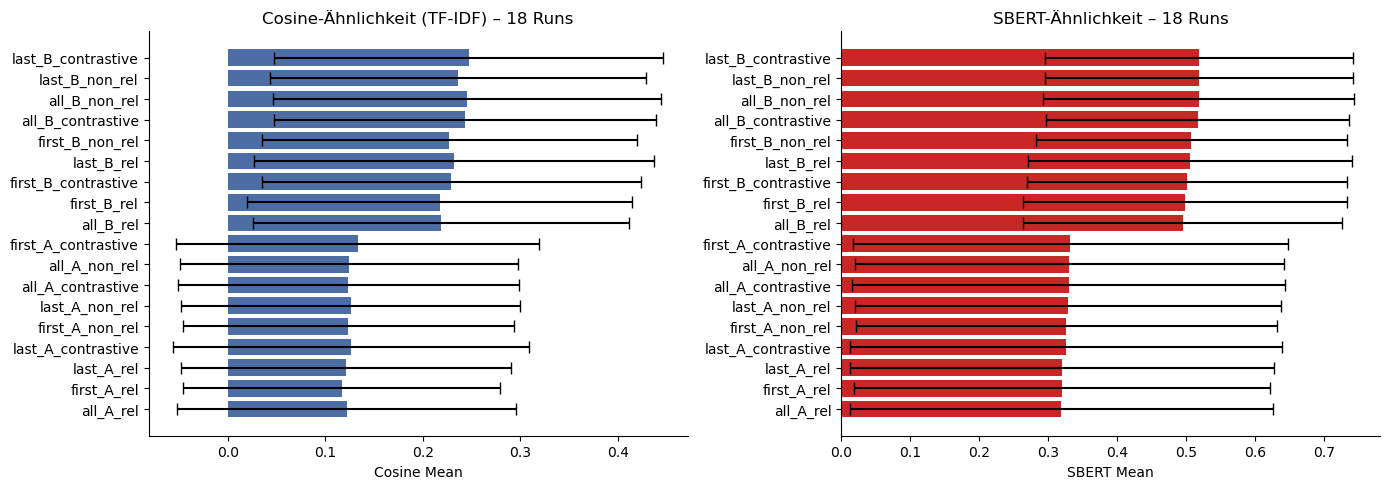

Chart gespeichert: data/task3_evaluation_chart.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sortiert nach SBERT Mean
df_plot = results_df.sort_values('SBERT Mean', ascending=True)
short_names = df_plot['Run'].str.replace('openai_', '', regex=False)

# Cosine
axes[0].barh(short_names, df_plot['Cosine Mean'], xerr=df_plot['Cosine Std'],
             color='#2E5496', alpha=0.85, capsize=4)
axes[0].set_xlabel('Cosine Mean')
axes[0].set_title('Cosine-Ähnlichkeit (TF-IDF) – 18 Runs')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# SBERT
axes[1].barh(short_names, df_plot['SBERT Mean'], xerr=df_plot['SBERT Std'],
             color='#C00000', alpha=0.85, capsize=4)
axes[1].set_xlabel('SBERT Mean')
axes[1].set_title('SBERT-Ähnlichkeit – 18 Runs')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'task3_evaluation_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart gespeichert: data/task3_evaluation_chart.png')